In [16]:
library(hdf5r)
library(Seurat)
library(ggplot2)
library(stringr)
#####feature plot
library(Seurat)
library(ggplot2)
library(cowplot)
library(dplyr)
library(tidyr)
library(stringr)
library(viridis)
library(reshape2)
library(patchwork)
library(ggplot2)
library(ggridges)
library(RColorBrewer)
library(scales)
library(stringr)
library(Seurat)
library("FactoMineR")
library(ggplot2)
library(vegan)
library(ape)
library(phyloseq)
library(ggalt)
library(microeco)
library(jsd)
library("factoextra")
library(Seurat)
library(stringr)
library(ggplot2)
library(pheatmap)
library(dplyr)
library(Seurat)
library(GSVA)
library(limma)
library(pheatmap)
library(ggplot2)

In [17]:
setwd("./03bulk_fn/")

In [18]:
sp <- readRDS("./bulk_mer_common.RDS")
sp@meta.data$sample <- sp@meta.data$chip_id

In [19]:
m <- read.csv("human_st_20260112.csv",row.names=1)
head(m)

,chip_id,chip,group,version,type,stage,tissue,tissue1,sample,stage_1,stage_ud,adventitia
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,A01189E1_1,A01189E1,NCR1,202506,BJ,NA,Carotid artery,carotid artery,save,late,late,none
2,A01189E3_1,A01189E3,NCR1,202506,BJ,NA,Carotid artery,carotid artery,save,late,late,none
3,A05862E3_1,A05862E3,this paper,202504,SZ,late,Carotid artery,carotid artery,filter,late,late,none
4,A05862E3_2,A05862E3,this paper,202504,SZ,late,Carotid artery,carotid artery,filter,late,late,none
5,A05872E5_1,A05872E5,this paper,202504,SZ,late,Carotid artery,carotid artery,save,late,late,none
6,A05872E5_2,A05872E5,this paper,202504,SZ,late,Carotid artery,carotid artery,save,late,late,none


In [20]:
sp@meta.data$sample_filter <- "NA"
sp@meta.data$stage_ud <- "NA"
sp@meta.data$adventitia <- "NA"
for(i in unique(m$chip_id)){
    sp@meta.data[which(sp@meta.data$sample==i),]$tissue <- m[which(m$chip_id==i),]$tissue
    sp@meta.data[which(sp@meta.data$sample==i),]$sample_filter <- m[which(m$chip_id==i),]$sample
    sp@meta.data[which(sp@meta.data$sample==i),]$stage_ud <- m[which(m$chip_id==i),]$stage_ud
    sp@meta.data[which(sp@meta.data$sample==i),]$stage_clin <- m[which(m$chip_id==i),]$stage_ud
    sp@meta.data[which(sp@meta.data$sample==i),]$adventitia <- m[which(m$chip_id==i),]$adventitia
}

In [238]:
sp

An object of class Seurat 
5175 features across 81 samples within 1 assay 
Active assay: RNA (5175 features, 0 variable features)

In [445]:
sp <- subset(sp,subset = sample_filter=="save")

In [446]:
Idents(pbmc) <- as.factor(pbmc@meta.data$tissue1)

In [447]:
####GSVA
gs <- read.csv("gs.csv")
# sp <-NormalizeData(sp)
sp1 <- AddModuleScore(sp,list(gs$plaque_gene))
colnames(sp1@meta.data) <- str_replace(colnames(sp1@meta.data),"Cluster1","score_addmodulescore")

Warning message:
“The following features are not present in the object: COMP, not searching for symbol synonyms”


In [449]:
as_gs <- list(gs$plaque_gene)
names(as_gs) <- "plaque"

In [450]:
exp <- as.data.frame(sp@assays$RNA@counts)
# 安装并加载 edgeR 包
# install.packages("BiocManager")
# BiocManager::install("edgeR")
library(edgeR)

# 假设你的表达矩阵名为 expr_mat
# 行是基因，列是样本

# 创建 DGEList 对象
dge <- DGEList(counts = exp)

# 计算 CPM
cpm_mat <- cpm(dge)

# 进行 log2(cpm+1) 转换
logcpm_mat <- log2(cpm_mat + 1)

# 查看结果
dim(logcpm_mat)
head(logcpm_mat[, 1:5])

[1] 5175   71

,A01189E1_1,A01189E3_1,A05872E5_1,A05872E5_2,A05872G1_1
A1CF,1.0149206,1.9459349,4.445895,4.027519,3.412761
A2M,11.5913248,11.6599395,10.152160,10.921203,10.994590
AADAC,0.3279149,0.9989218,3.560368,1.583380,3.176568
AADACL2,0.0000000,0.0000000,0.000000,0.000000,0.000000
ABCA1,8.7677120,7.9652835,9.356734,8.842076,7.387672
ABCA10,2.1930687,2.4388130,4.572527,4.641578,5.446923


In [451]:
sp <- NormalizeData(sp,scale.factor = 200000)

In [475]:
sp <- NormalizeData(sp)
exp1 <- as.data.frame(sp@assays$RNA@data)
expr <- exp1[names(sort(apply(exp1, 1, mad),decreasing = T)[1:5175]),]

In [476]:
meta <- sp@meta.data

In [540]:
gsva.res1 <- gsva(
    as.matrix(expr),
    as.list(as_gs),
    method="gsva",
    kcdf = "Gaussian",tau=1,
    mx.diff = F,
    verbose = F)

In [541]:
rownames(gsva.res1) <- "score_gsva"
gss <- as.data.frame(t(gsva.res1))

In [542]:
ssgsea <- gsva(
    as.matrix(expr),
    as.list(as_gs),
    method="ssgsea",
    kcdf = "Poisson",
    mx.diff = F,
    verbose = F)

In [543]:
rownames(ssgsea) <- "score_ssgsea"

In [544]:
score <- as.data.frame(t(rbind(gsva.res1,ssgsea)))
score$sample <- rownames(score)

In [545]:
###Poisson####Gaussian

In [546]:
sp1 <- sp

In [547]:
sp1@meta.data$score_gsva1 <- "NA"
sp1@meta.data$score_ssgsea1 <- "NA"
for(i in rownames(score)){
    score_gsva <- score[which(score$sample==i),]$score_gsva
    score_ssgsea <- score[which(score$sample==i),]$score_ssgsea
    sp1@meta.data[which(sp1@meta.data$chip_id==i),]$score_gsva1 <- score_gsva
    sp1@meta.data[which(sp1@meta.data$chip_id==i),]$score_ssgsea1 <- score_ssgsea
}

In [548]:
library(ggplot2)
library(geomtextpath)

In [549]:
sp <- sp1
sp@meta.data$iterms <- "AShuman"

In [550]:
color <- c("#DC143C","#20B2AA","#FFA500","#9370DB","#98FB98","#1E90FF","#7CFC00","#FFFF00","#808000","#FF00FF",
               "#FA8072","#7B68EE","#9400D3","#800080","#A0522D","#D2B48C",
               "#D2691E","#87CEEB","#40E0D0","#5F9EA0","#FF1493","#0000CD",
               "#008B8B","#FFE4B5","#8A2BE2","#228B22","#E9967A","#4682B4",
               "#32CD32","#F0E68C","#FFFFE0","#EE82EE","#FF6347","#6A5ACD",
               "#9932CC","#8B008B","#8B4513","#DEB887",
               "#B8DBB3","#72B063","#719AAC","#E29135","#94C6CD","#4A5F7E","#A5AEB7","#925EB0",
               "#7E99F4","#CC7C71","#7AB656","#8D2F25","#4E1945","#CB9475","#8CBF87","#3E608D",
               "#909291","#B7B7EB","#9D9EA3","#EAB883","#9BBBE1","#F09BA0","#DDDDDD","#E6B745",
               "#D0DD97","#DCA7EB","#A0D0D0","#EAE936","#B7F5DE","#D5AABE","#A7C0DF","#A51C36",
               "#7ABBDB","#84BA42","#682487","#DBB428","#D4562E","#4485C7","#6F6F6F","#547BB4",
               "#C0321A","#629C35","#DD7C4F","#6C61AF","#8074C8","#7895C1","#A8CBDF","#D6EFF4",
               "#F2FAFC","#992224","#B54764","#E3625D","#EF8B67","#F0C284","#F5EBAE","#F7FBC9",
               "#3E4F94","#3E90BF","#58B6E9","#A6C0E3","#D8D3E7","#FAF9CB","#BFDFD2","#257D8B",
               "#68BED9","#EFCE87","#EAA558","#ED8D5A","#979998","#C69287","#E79A90","#EFBC91",
               "#E4CD87","#FAE5B8","#DDDDDF","#E4A031","#D68438","#C76B60","#B55384","#7C4D77",
               "#474769","#26445E","#4C7780","#73A5A2","#F6E2C1","#F3DBC1","#B2B6C1","#D6E2E2",
               "#F0EFED","#D8B365","#5BB5AC","#DE526C","#2472A3","#A5B55D","#F4F3EE","#B02425",
               "#FAA419","#4583B6","#4DB748","#218D42","#156434","#FAA419","#4583B6","#4DB748",
               "#1F8E42","#156434","#7EA6D9","#D4E6BC","#F8F2A4","#A04646","#CFC580","#75AAB8",
               "#DCCB59","#2900F2","#AE3019","#B58C9A","#8985B7","#E8DF92","#A3C98E","#B3C4D4",
               "#807C7D","#C1565E","#DCA96A","#82AD7F","#7EA4D1","#79438E","#FDEBAA","#EDC3A5",
               "#DBE4FB","#ABD1BC","#E3BBED","#CCCC99","#BED0F9","#FCB6A5","#F1F1F1","#F0EEEF",
               "#C6CCDC","#9DACCB","#7789B7","#CBD7C3","#ACBF9F","#89AA7B","#D6D6D6","#EB6969",
               "#18BECF","#BCBD23","#7F7F7F","#004600","#78B428","#C8E63C","#FFE494","#32183C",
               "#A21A54","#E7724F","#36659E","#40B7AD","#FFC04D","#82093B","#34183E","#4D779B",
               "#C45C69","#CD3B42","#585D5E","#2B5863","#6A8078","#08306B","#08519C","#2171B5",
               "#6BAED6","#C6DBEF","#FED976","#FFFFCC","#D95319","#EDB120","#0072BD","#77AC30")

In [551]:
sp@meta.data$score_gsva1 <- as.numeric(sp@meta.data$score_gsva1)
# sp@meta.data$score_gsva1 <- scale(sp@meta.data$score_gsva1)

In [552]:
sp@meta.data$stage_ann1 <- "NA"
sp@meta.data[which(sp@meta.data$score_gsva1<= -0.5),]$stage_ann1 <- "stage1"
sp@meta.data[which(sp@meta.data$score_gsva1> -0.5&sp@meta.data$score_gsva1<= 0),]$stage_ann1 <- "stage2"
sp@meta.data[which(sp@meta.data$score_gsva1> 0&sp@meta.data$score_gsva1<=0.5),]$stage_ann1 <- "stage3"
sp@meta.data[which(sp@meta.data$score_gsva1> 0.5),]$stage_ann1 <- "stage4"

In [25]:
table(sp@meta.data$stage_ann1)


stage1 stage2 stage3 stage4 
    20     21     12     18 

In [26]:
mer <- sp@meta.data

In [27]:
m <- as.matrix(table(as.character(mer$stage_ann1), mer$tissue))
m

        
         Abdominal aorta Carotid artery Coronary artery Iliac artery
  stage1               3              3               0            2
  stage2               0              7               6            3
  stage3               3              1               5            2
  stage4               0             18               0            0
        
         Lower limb artery Thoracic aorta
  stage1                 7              5
  stage2                 2              3
  stage3                 1              0
  stage4                 0              0

In [28]:
cols1=c('normal'="#8CE4FF",'early'="#007F73",'median'="#FFC700",'late'="#f16c23")
cols2= c('Carotid artery plaque'="#A6FF96",'Common iliac artery'="#F8FF95",'Abdominal aorta'="#BC7AF9",'Coronary artery'="#E67E22",'Thoracic aorta'="#932F67",'Lower limb artery occlusion'="#F6FF99")
cols3= c('NCR1'="#40B7AD",'NCR2'="#FAA419",'this paper'="#df65b0")
cols5= c('stage1'="#a7d3d4",'stage2'="#009b9e",'stage3'="#e4c1d9",'stage4'="#c75dab")
cols1 <- c('normal'='#63C8FF','early'='#4DFFBE','median'='#FDFFB8','late'='#FF2DD1')

        
         early late median normal
  stage1     9    5      3      3
  stage2     6    9      2      4
  stage3     0    3      9      0
  stage4     0   18      0      0

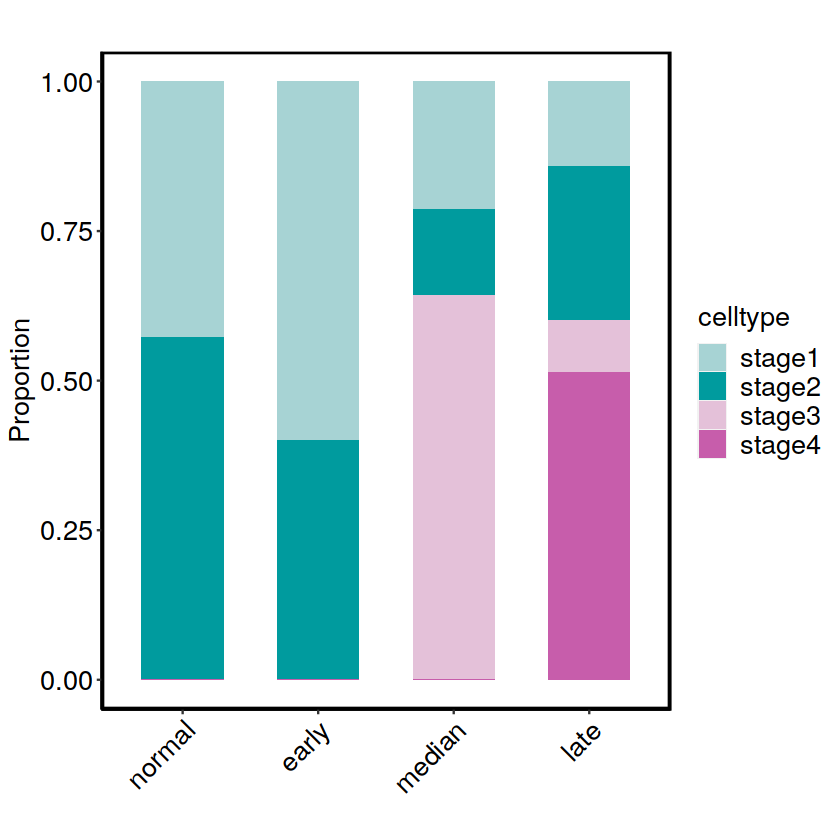

In [29]:
m <- as.matrix(table(as.character(mer$stage_ann1), mer$stage_ud))
m
plot_df <- melt(m)
colnames(plot_df) <- c('celltype','y','sum')
plot_df$celltype <- factor(plot_df$celltype, levels = c("stage1","stage2","stage3","stage4"))
plot_df$y <- factor(plot_df$y, levels = c("normal","early","median","late"))
plot_df$score <- NA
plot_df$cor <- 0
for (a in 1:nrow(plot_df)) {
  plot_df[a,'score'] <- sum(plot_df$sum[which(plot_df$y==plot_df$y[a])])
}
p1 <- ggplot(plot_df, mapping = aes(y,sum,fill=celltype))+geom_bar(stat='identity',width = 0.6,position="fill")+
labs(x = "",y = 'Proportion',title = "") +theme(axis.title =element_text(size = 16),axis.text =element_text(size = 14, color = 'black'))+
theme(
    plot.title    = element_text(color = 'black', size   = 20, hjust = 0.5),
    plot.subtitle = element_text(color = 'black', size   = 16,hjust = 0.5),
    plot.caption  = element_text(color = 'black', size   = 16,face = 'italic', hjust = 1),
    axis.text.x   = element_text(color = 'black', size = 16, angle = 45,hjust = 1),
    axis.text.y   = element_text(color = 'black', size = 16, angle = 0),
    axis.title.x  = element_text(color = 'black', size = 16, angle = 0),
    axis.title.y  = element_text(color = 'black', size = 16, angle = 90),
    legend.title  = element_text(color = 'black', size  = 16),
    legend.text   = element_text(color = 'black', size   = 16),
    axis.line.y = element_line(color = 'black', linetype = 'solid'), # y轴线特征
    axis.line.x = element_line (color = 'black',linetype = 'solid'), # x轴线特征
    panel.background=element_rect(fill="white"),
    panel.border = element_rect(linetype = 'solid', size = 1.2,fill = NA) # 图四周框起来
  )+scale_fill_manual(values = cols5)
p1

In [30]:
colnames(mer)

[1] "orig.ident"    "nCount_RNA"    "nFeature_RNA"  "chip_id"      
 [5] "chip"          "group"         "version"       "type"         
 [9] "stage"         "tissue"        "tissue1"       "sample"       
[13] "stage_1"       "stage_clin"    "sample_filter" "stage_ud"     
[17] "adventitia"    "score_gsva1"   "score_ssgsea1" "iterms"       
[21] "stage_ann1"

        
         early late median normal
  stage2     2    4      0      3
  stage3     0    1      4      0
  stage4     0   13      0      0

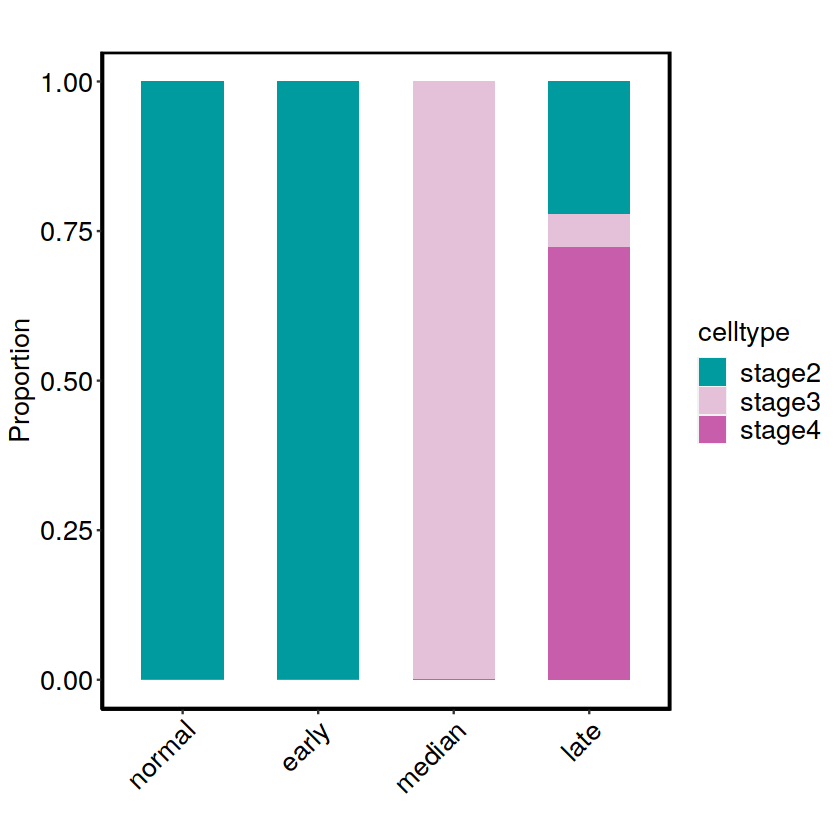

In [31]:
mer1 <- mer[which(mer$sample_filter=="save"&mer$group!="this paper"),]
m <- as.matrix(table(as.character(mer1$stage_ann1), mer1$stage_ud))
m
plot_df <- melt(m)
colnames(plot_df) <- c('celltype','y','sum')
plot_df$celltype <- factor(plot_df$celltype, levels = c("stage1","stage2","stage3","stage4"))
plot_df$y <- factor(plot_df$y, levels = c("normal","early","median","late"))
plot_df$score <- NA
plot_df$cor <- 0
for (a in 1:nrow(plot_df)) {
  plot_df[a,'score'] <- sum(plot_df$sum[which(plot_df$y==plot_df$y[a])])
}
p1 <- ggplot(plot_df, mapping = aes(y,sum,fill=celltype))+geom_bar(stat='identity',width = 0.6,position="fill")+
labs(x = "",y = 'Proportion',title = "") +theme(axis.title =element_text(size = 16),axis.text =element_text(size = 14, color = 'black'))+
theme(
    plot.title    = element_text(color = 'black', size   = 20, hjust = 0.5),
    plot.subtitle = element_text(color = 'black', size   = 16,hjust = 0.5),
    plot.caption  = element_text(color = 'black', size   = 16,face = 'italic', hjust = 1),
    axis.text.x   = element_text(color = 'black', size = 16, angle = 45,hjust = 1),
    axis.text.y   = element_text(color = 'black', size = 16, angle = 0),
    axis.title.x  = element_text(color = 'black', size = 16, angle = 0),
    axis.title.y  = element_text(color = 'black', size = 16, angle = 90),
    legend.title  = element_text(color = 'black', size  = 16),
    legend.text   = element_text(color = 'black', size   = 16),
    axis.line.y = element_line(color = 'black', linetype = 'solid'), # y轴线特征
    axis.line.x = element_line (color = 'black',linetype = 'solid'), # x轴线特征
    panel.background=element_rect(fill="white"),
    panel.border = element_rect(linetype = 'solid', size = 1.2,fill = NA) # 图四周框起来
  )+scale_fill_manual(values = cols5)
p1

        
         early late median normal
  stage1     9    5      3      3
  stage2     4    5      2      1
  stage3     0    2      5      0
  stage4     0    5      0      0

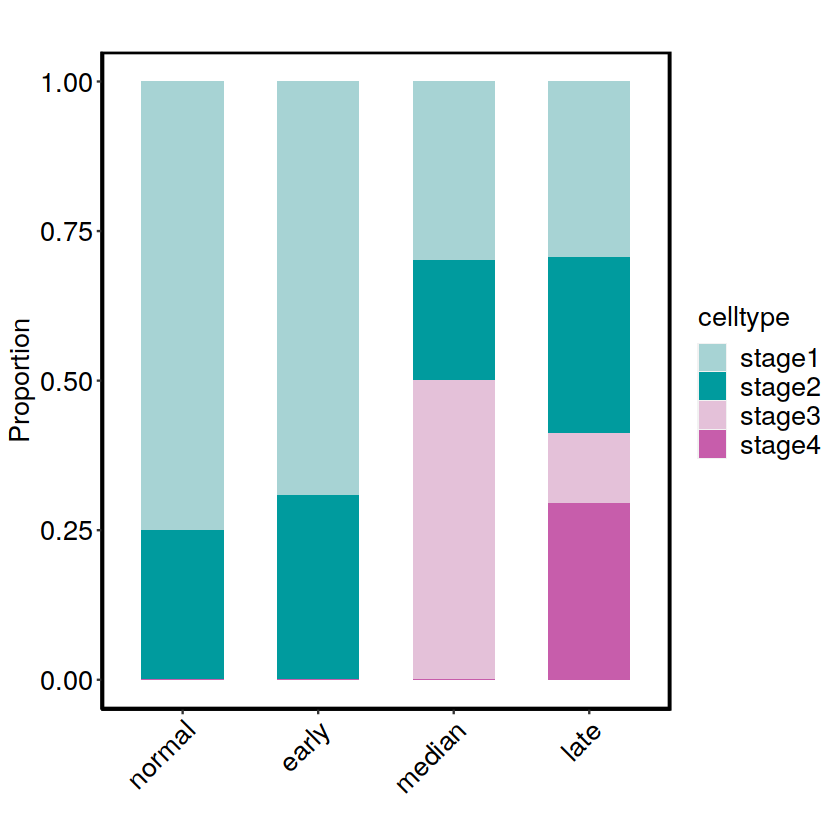

In [32]:
mer1 <- mer[which(mer$sample_filter=="save"&mer$group=="this paper"),]
m <- as.matrix(table(as.character(mer1$stage_ann1), mer1$stage_ud))
m
plot_df <- melt(m)
colnames(plot_df) <- c('celltype','y','sum')
plot_df$celltype <- factor(plot_df$celltype, levels = c("stage1","stage2","stage3","stage4"))
plot_df$y <- factor(plot_df$y, levels = c("normal","early","median","late"))
plot_df$score <- NA
plot_df$cor <- 0
for (a in 1:nrow(plot_df)) {
  plot_df[a,'score'] <- sum(plot_df$sum[which(plot_df$y==plot_df$y[a])])
}
p1 <- ggplot(plot_df, mapping = aes(y,sum,fill=celltype))+geom_bar(stat='identity',width = 0.6,position="fill")+
labs(x = "",y = 'Proportion',title = "") +theme(axis.title =element_text(size = 16),axis.text =element_text(size = 14, color = 'black'))+
theme(
    plot.title    = element_text(color = 'black', size   = 20, hjust = 0.5),
    plot.subtitle = element_text(color = 'black', size   = 16,hjust = 0.5),
    plot.caption  = element_text(color = 'black', size   = 16,face = 'italic', hjust = 1),
    axis.text.x   = element_text(color = 'black', size = 16, angle = 45,hjust = 1),
    axis.text.y   = element_text(color = 'black', size = 16, angle = 0),
    axis.title.x  = element_text(color = 'black', size = 16, angle = 0),
    axis.title.y  = element_text(color = 'black', size = 16, angle = 90),
    legend.title  = element_text(color = 'black', size  = 16),
    legend.text   = element_text(color = 'black', size   = 16),
    axis.line.y = element_line(color = 'black', linetype = 'solid'), # y轴线特征
    axis.line.x = element_line (color = 'black',linetype = 'solid'), # x轴线特征
    panel.background=element_rect(fill="white"),
    panel.border = element_rect(linetype = 'solid', size = 1.2,fill = NA) # 图四周框起来
  )+scale_fill_manual(values = cols5)
p1